c:\Users\XB926SS\OneDrive - EY\Documents\GitHub\house-price-tracker\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\XB926SS\AppData\Local\Temp\ipykernel_28256\872750600.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lisbon_centroid.drop(['geometry'], axis=1, inplace=True)
C:\Users\XB926SS\AppData\Local\Temp\ipykernel_28256\872750600.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentati

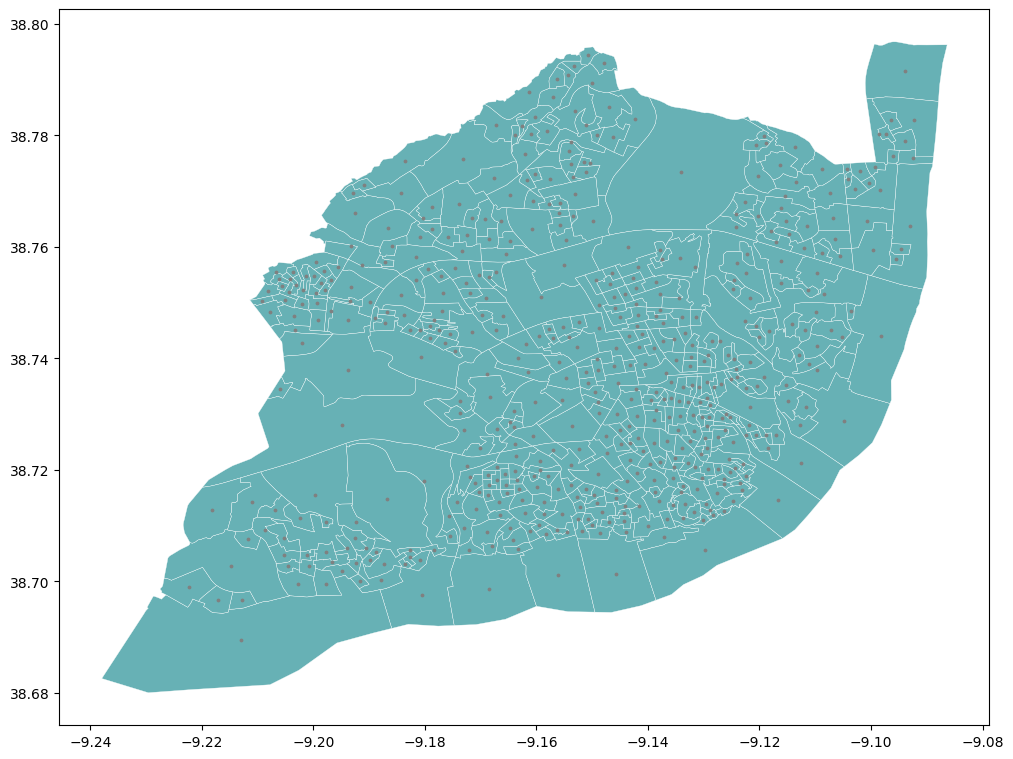

In [1]:
import geopandas as gpd
from geopandas import GeoDataFrame
from geopandas.tools import sjoin
from shapely.geometry import Point

import pandas as pd
import math

import zipfile
import requests
import io

import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from matplotlib.colors import ListedColormap

# census data from Lisbon-PT
url = 'https://mapas.ine.pt/download/filesGPG/2021/municipios/BGRI2021_1106.zip'
filename = 'BGRI2021_1106.gpkg'

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extract(filename)

# openlisbon shape
lisbon = gpd.read_file(filename)

# select only numerical columns of census data
census_col = [x for x in lisbon.columns.to_list() if x.startswith('N_')]

# union on statistical section
lisbon_statistical_section = lisbon[census_col + ['DTMNFRSEC21', 'geometry']].dissolve(by='DTMNFRSEC21', aggfunc='sum').reset_index()

# separate a df with only the statistical section id and centroid. the geodataframe does not support two geometries
lisbon_centroid = lisbon_statistical_section[['DTMNFRSEC21', 'geometry']]
lisbon_centroid['centroid'] = lisbon_centroid['geometry'].centroid

#drop geometry
lisbon_centroid.drop(['geometry'], axis=1, inplace=True)
lisbon_centroid.rename(columns={'centroid': 'geometry'}, inplace=True)

# convert to WGS84 (latitude and longitude as known for global)
lisbon_statistical_section = lisbon_statistical_section.to_crs(epsg=4326)
lisbon_centroid = lisbon_centroid.to_crs(epsg=4326)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

lisbon_statistical_section.plot(aspect=1,
                                     edgecolor="white",
                                     linewidth=0.25,
                                     color='#67B1B5',
                                     ax=ax)

lisbon_centroid.plot(aspect=1,
                          color='gray',
                          markersize=3,
                          ax=ax);